In [ ]:
pip install yfinance

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
import yfinance as yfin
yfin.pdr_override()

In [ ]:
start = '2015-09-01'
end = '2023-03-02'

df = pdr.get_data_yahoo('LTC-USD', start, end)
df.head()

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-09-01,2.84742,2.87549,2.80563,2.82001,2.82001,1376040
2015-09-02,2.81981,2.82813,2.75730,2.79545,2.79545,2423010
2015-09-03,2.79669,2.80446,2.57997,2.63314,2.63314,2210590
2015-09-04,2.63814,2.72467,2.63334,2.70112,2.70112,1441530
2015-09-05,2.70205,2.94305,2.66153,2.91954,2.91954,2666820


In [ ]:
df.drop(['Open','High','Low','Volume'], axis = 1,inplace = True)

In [ ]:
df.drop(['Adj Close'],axis = 1, inplace = True)

In [ ]:
df

,Close
Date,
2015-09-01,2.820010
2015-09-02,2.795450
2015-09-03,2.633140
2015-09-04,2.701120
2015-09-05,2.919540
...,...
2023-02-25,93.263451
2023-02-26,95.255623
2023-02-27,94.086678


In [ ]:
train_data = df[:'2022']
test_data = df['2022':]
train_data = np.array(train_data)
test_data = np.array(test_data)
test_data.shape

(425, 1)

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
history = [x for x in train_data]
predictions = list()
# walk-forward validation
for t in range(len(test_data)):
 model = ARIMA(history, order=(3,1,2))
 model_fit = model.fit()
 output = model_fit.forecast()
 yhat = output[0]
 predictions.append(yhat)
 obs = test_data[t]
 history.append(obs)
 print('predicted=%f, expected=%f' % (yhat, obs))
# evaluate forecasts
#rmse = sqrt(mean_squared_error(test, predictions))
#print('Test RMSE: %.3f' % rmse)

/usr/local/lib/python3.9/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.9/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


predicted=69.982727, expected=150.697433
predicted=149.637099, expected=151.255493
predicted=154.552388, expected=148.461594
predicted=148.110820, expected=146.812286
predicted=148.397157, expected=136.089111
predicted=135.935591, expected=136.503784
predicted=136.900426, expected=131.488449
predicted=131.481539, expected=130.137482
predicted=130.178798, expected=131.298325
predicted=131.225781, expected=126.833824
predicted=126.956312, expected=131.544983
predicted=131.282319, expected=141.737198
predicted=141.836270, expected=136.636520
predicted=136.932485, expected=144.724915
predicted=144.492688, expected=147.937408
predicted=148.333811, expected=146.533203
predicted=146.555475, expected=151.667267
predicted=151.765402, expected=141.890762
predicted=142.218967, expected=136.916702
predicted=136.696255, expected=130.365005
predicted=130.434226, expected=114.391869
predicted=114.229944, expected=108.428497
predicted=107.944997, expected=112.089508
predicted=111.730480, expected=109.

In [ ]:
from sklearn.metrics import mean_squared_error
from math import sqrt
rmse = sqrt(mean_squared_error(test_data, predictions))
print('Test RMSE: %.3f' % rmse)


Test RMSE: 5.339


In [ ]:
train_data

array([[ 2.82000995],
       [ 2.79544997],
       [ 2.63314009],
       ...,
       [66.75107574],
       [67.99403381],
       [69.99621582]])

In [ ]:
predictions


[69.9827273640042,
 149.63709901222944,
 154.55238800657114,
 148.11082023246692,
 148.39715692575706,
 135.93559111448286,
 136.90042625393517,
 131.48153871895082,
 130.17879831275442,
 131.22578073840202,
 126.95631207162005,
 131.2823187053414,
 141.83626980788054,
 136.93248529107953,
 144.49268801096625,
 148.33381059657023,
 146.5554746728294,
 151.7654018461096,
 142.21896715069383,
 136.69625457129524,
 130.43422635020224,
 114.22994435925585,
 107.94499741150787,
 111.73047978253302,
 109.49623480305536,
 107.80820175927533,
 107.18470489061465,
 106.79152220356949,
 109.34044032975969,
 110.81102495171417,
 108.82903766779476,
 109.50074850113752,
 115.37349217221671,
 108.8034991959498,
 110.0123106240386,
 120.96788024789548,
 122.13924597992468,
 127.45896975639903,
 137.31261075772645,
 134.39062445758205,
 140.11184913269267,
 135.57866990338755,
 125.93402979370188,
 126.60010907654478,
 126.16296690592888,
 124.75807264013999,
 131.60618670006167,
 128.42755366676505,

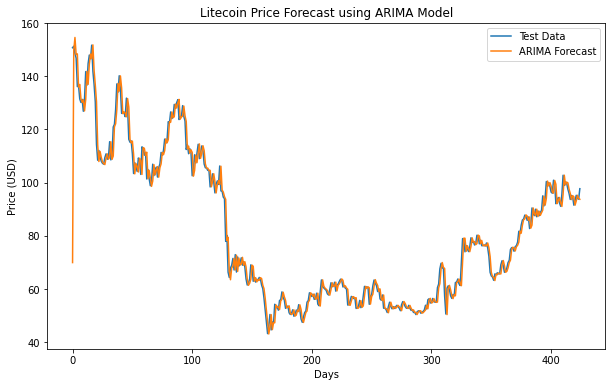

In [ ]:
plt.figure(figsize=(10,6))
#plt.plot(train_data[1:], label='Train Data')
plt.plot(test_data, label='Test Data')
plt.plot(predictions, label='ARIMA Forecast')
plt.legend()
plt.title('Litecoin Price Forecast using ARIMA Model')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.show()

In [ ]:
def MAPE(Y_actual,Y_Predicted):
    mape = np.mean(np.abs((Y_actual - Y_Predicted)/Y_actual))*100
    return mape

In [ ]:
LR_MAPE= MAPE(test_data,predictions)
print("MAPE: ",LR_MAPE)

MAPE:  39.42589715524566
